In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ==========================================
# Task 5: Sales Data Analysis
# Dataset: Superstore Sales Dataset
# ==========================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:

# ------------------------------------------
# Display Available Files
# ------------------------------------------

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv


In [4]:

# ------------------------------------------
# Load Dataset
# ------------------------------------------

# Update path if necessary
df = pd.read_csv('/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv')

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape: (9800, 18)

First 5 Rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal

In [5]:

# ------------------------------------------
# Dataset Information
# ------------------------------------------

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float6

In [7]:

# ------------------------------------------
# Convert Date Column
# ------------------------------------------

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

# Extract Date Features

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Year'] = df['Order Date'].dt.to_period('M')


In [8]:

# ------------------------------------------
# Summary Statistics
# ------------------------------------------

print("\nSummary Statistics:")
print(df.describe())



Summary Statistics:
            Row ID                     Order Date   Postal Code         Sales  \
count  9800.000000                           9800   9789.000000   9800.000000   
mean   4900.500000  2017-05-01 05:13:51.673469440  55273.322403    230.769059   
min       1.000000            2015-01-03 00:00:00   1040.000000      0.444000   
25%    2450.750000            2016-05-24 00:00:00  23223.000000     17.248000   
50%    4900.500000            2017-06-26 00:00:00  58103.000000     54.490000   
75%    7350.250000            2018-05-15 00:00:00  90008.000000    210.605000   
max    9800.000000            2018-12-30 00:00:00  99301.000000  22638.480000   
std    2829.160653                            NaN  32041.223413    626.651875   

              Year        Month  
count  9800.000000  9800.000000  
mean   2016.724184     7.818469  
min    2015.000000     1.000000  
25%    2016.000000     5.000000  
50%    2017.000000     9.000000  
75%    2018.000000    11.000000  
max    2018

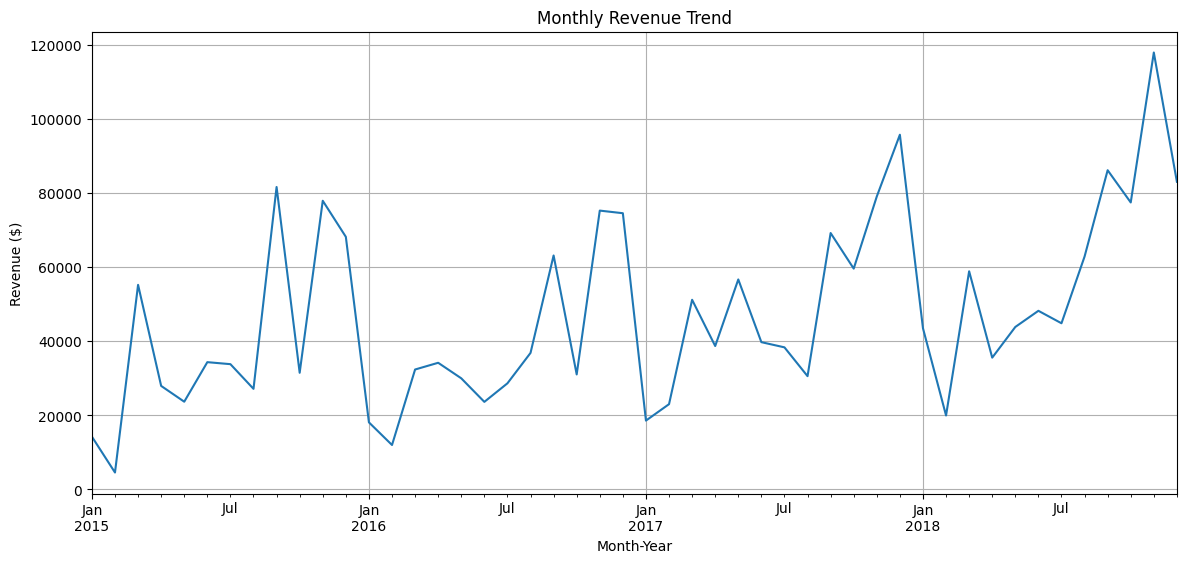

In [9]:

# ==========================================
# Monthly Revenue Trend
# ==========================================

monthly_sales = df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month-Year')
plt.ylabel('Revenue ($)')
plt.grid(True)

plt.show()


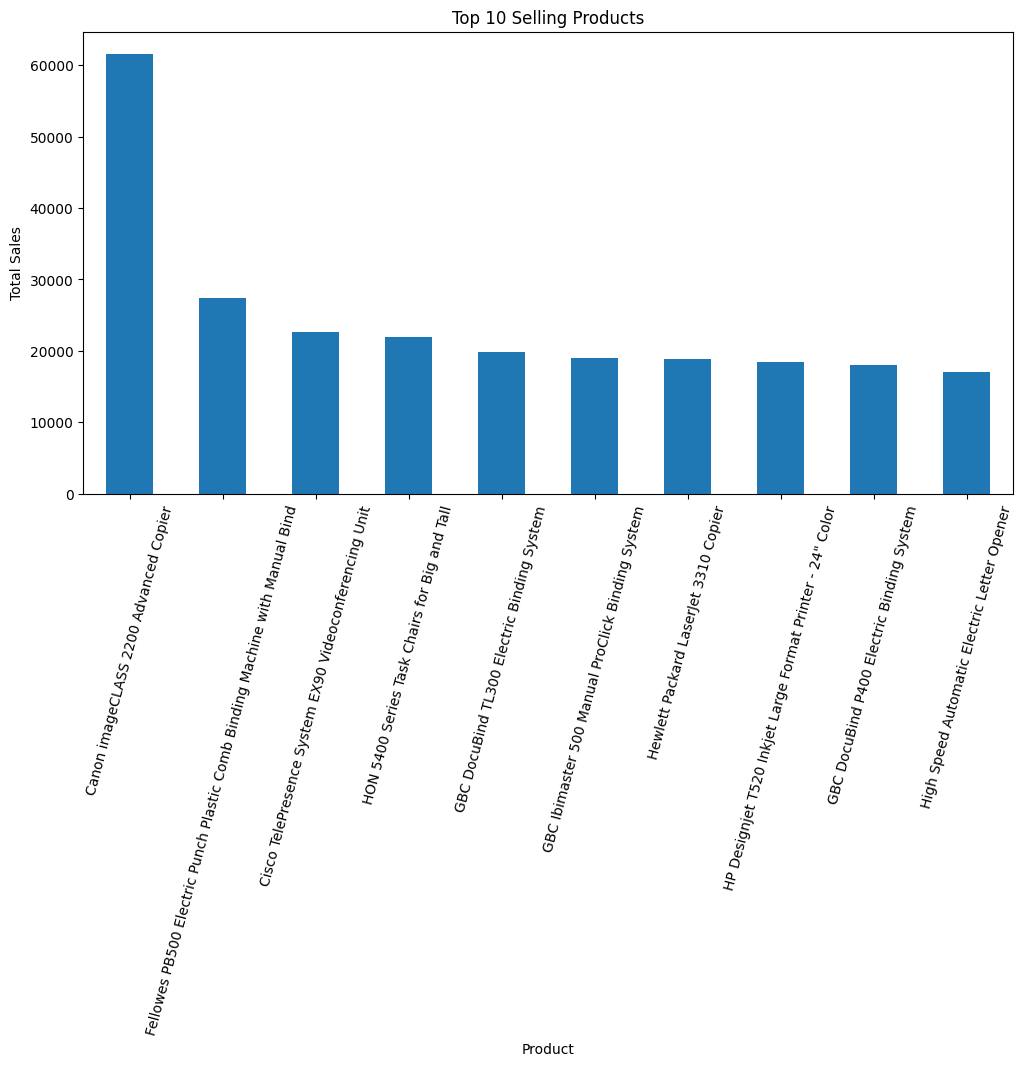


Top Selling Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [10]:

# ==========================================
# Top Selling Products
# ==========================================

top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Total Sales')

plt.xticks(rotation=75)

plt.show()

print("\nTop Selling Products:")
print(top_products)


In [13]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Month_Year']


In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Year
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,2017-11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,2017-11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2017-06
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,2016-10
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,2016-10


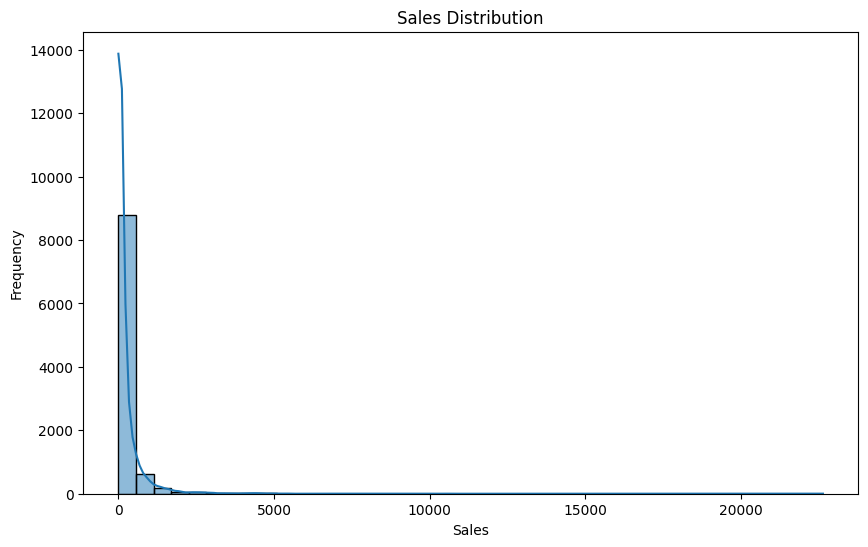

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Sales'],
    bins=40,
    kde=True
)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

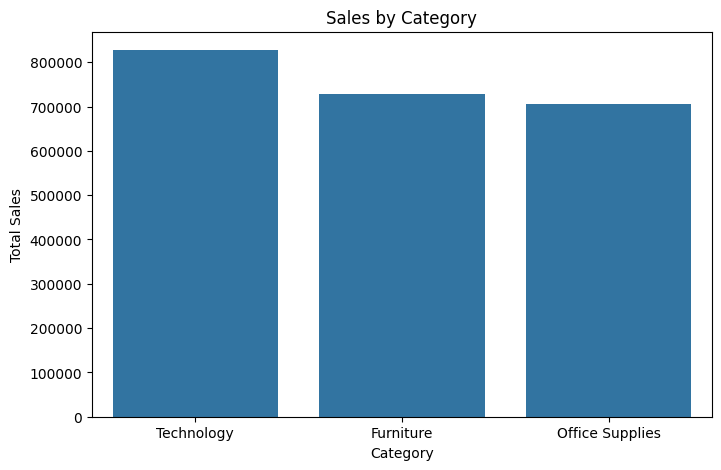

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [16]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

print(category_sales)

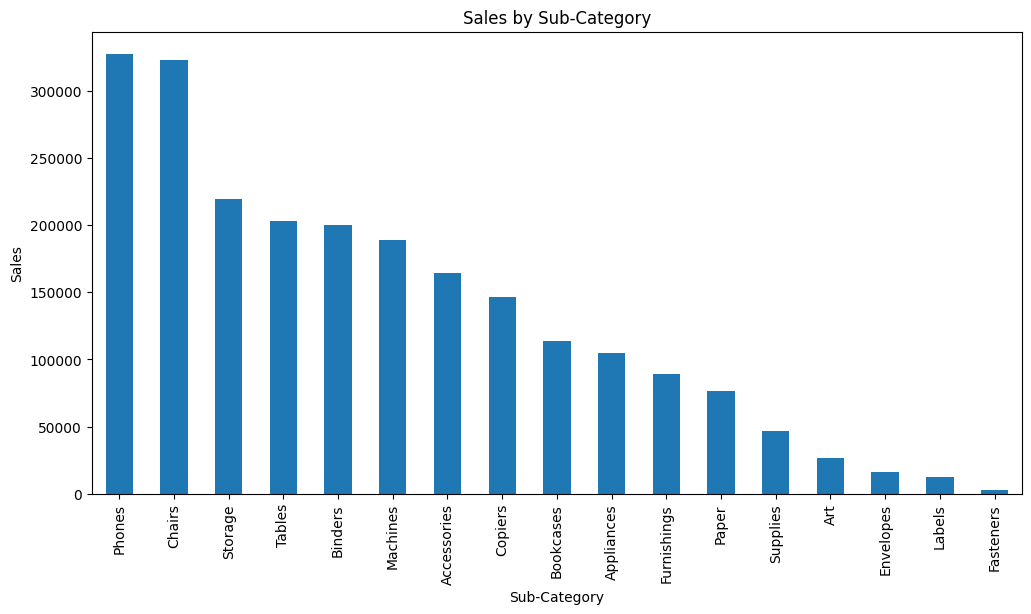

In [17]:
subcat_sales = (
    df.groupby('Sub-Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

subcat_sales.plot(kind='bar')

plt.title('Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')

plt.show()

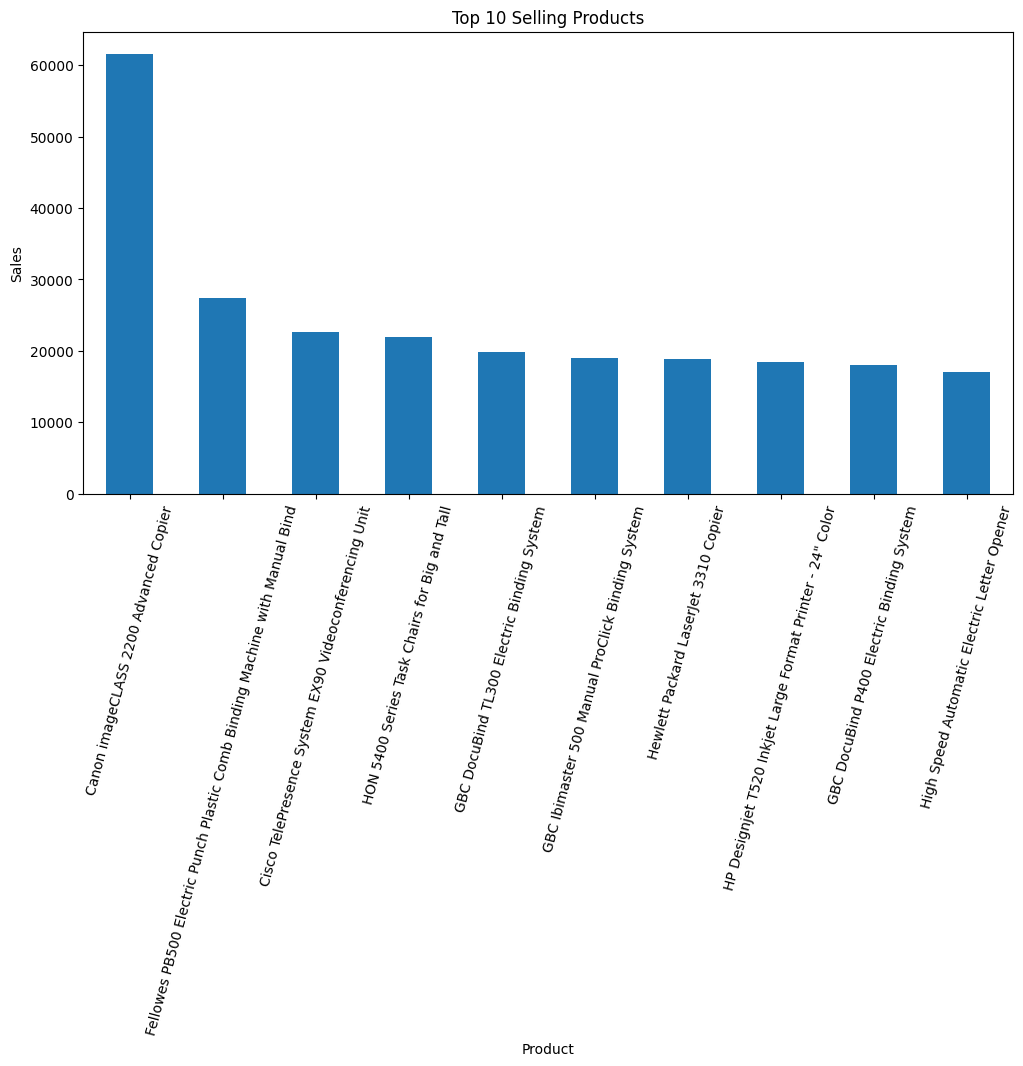

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [18]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Sales')

plt.xticks(rotation=75)

plt.show()

print(top_products)

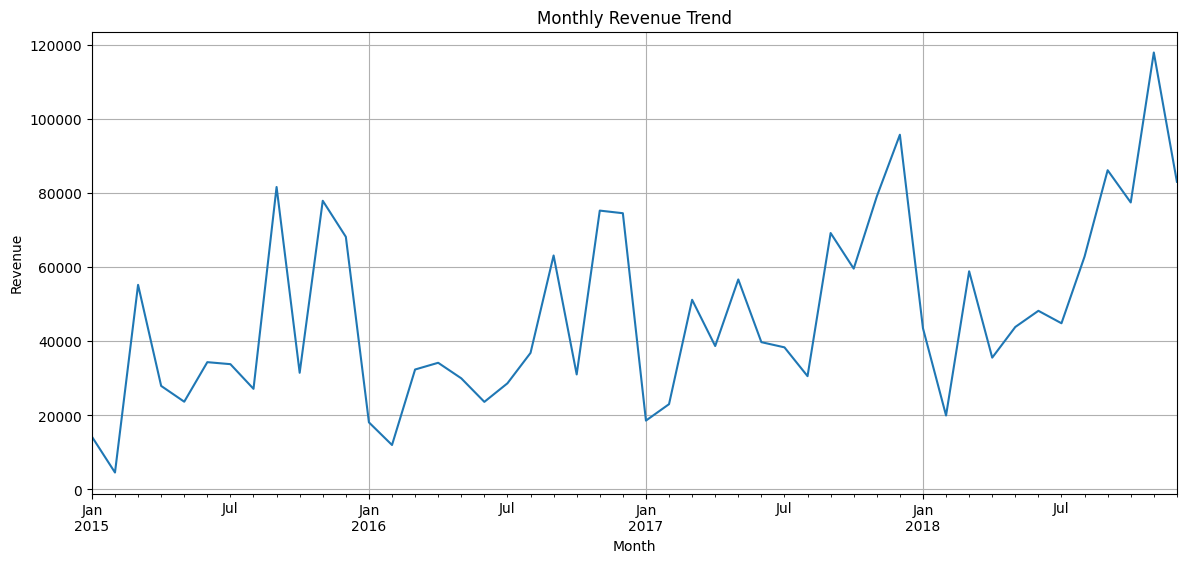

In [19]:
monthly_sales = (
    df.groupby('Month_Year')['Sales']
      .sum()
)

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

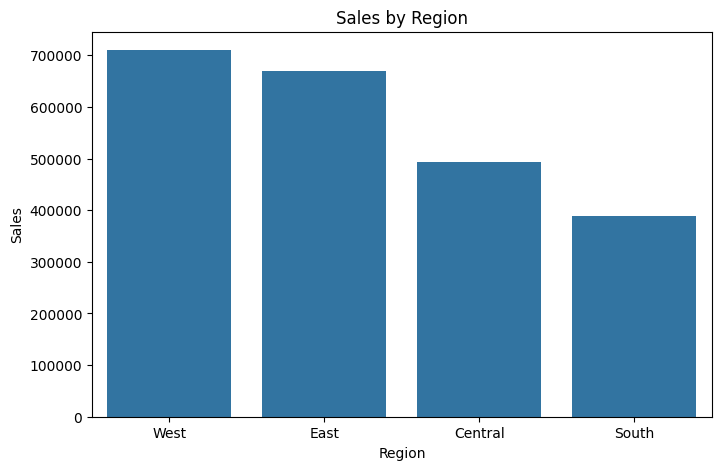

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [20]:
region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

print(region_sales)

In [23]:
print("="*60)
print("BUSINESS INSIGHTS REPORT")
print("="*60)

print(f"\nTotal Revenue: ${df['Sales'].sum():,.2f}")
print(f"Total Orders : {len(df):,}")

print("\nTop Revenue Category:")
print(df.groupby('Category')['Sales'].sum().idxmax())

print("\nTop Revenue Region:")
print(df.groupby('Region')['Sales'].sum().idxmax())

print("\nTop Selling Product:")

top_product = (
    df.groupby('Product Name')['Sales']
      .sum()
      .idxmax()
)

print(top_product)

print("""
Key Insights:

1. Technology and Office Supplies generate significant revenue.

2. A small number of products contribute a large share of sales.

3. Revenue shows seasonal fluctuations across months.

4. Some regions outperform others in total sales.

5. Understanding product-wise performance can help optimize inventory.

6. Monthly sales trends can support future sales forecasting.
""")

BUSINESS INSIGHTS REPORT

Total Revenue: $2,261,536.78
Total Orders : 9,800

Top Revenue Category:
Technology

Top Revenue Region:
West

Top Selling Product:
Canon imageCLASS 2200 Advanced Copier

Key Insights:

1. Technology and Office Supplies generate significant revenue.

2. A small number of products contribute a large share of sales.

3. Revenue shows seasonal fluctuations across months.

4. Some regions outperform others in total sales.

5. Understanding product-wise performance can help optimize inventory.

6. Monthly sales trends can support future sales forecasting.

